# 🤖 Démo — Assistant Python / Data Science / ML (Qwen2.5-3B fine-tuné QLoRA)

Ce notebook présente, de bout en bout, un **LLM fine-tuné en local** sur une
**RTX 4070 Laptop (8 Go)** avec **QLoRA** (LoRA + quantization 4-bit) :

1. Configuration & environnement
2. Le dataset (domaine Python/DS/ML)
3. Courbe d'apprentissage
4. Gain mesuré du fine-tuning (ROUGE / BLEU vs modèle de base)
5. Démonstration en direct

> Modèle de base : `Qwen/Qwen2.5-3B-Instruct` · Méthode : QLoRA (rang 16, 4-bit NF4)

## 1. Configuration & environnement

In [1]:
import sys, os, json
from pathlib import Path

# Rendre le projet importable, quel que soit le repertoire d'execution
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import torch
from src.config import Config

cfg = Config()
print("Modele de base :", cfg.model.model_name)
print("Quantization   :", "4-bit " + cfg.model.bnb_4bit_quant_type if cfg.model.use_4bit else "aucune")
print("LoRA           : rang", cfg.lora.r, "| alpha", cfg.lora.alpha,
      "|", len(cfg.lora.target_modules), "modules cibles")
print("GPU            :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Modele de base : Qwen/Qwen2.5-3B-Instruct
Quantization   : 4-bit nf4
LoRA           : rang 16 | alpha 32 | 7 modules cibles
GPU            : NVIDIA GeForce RTX 4070 Laptop GPU


## 2. Le dataset

Un corpus **curé** de paires question/réponse expertes sur Python, NumPy/Pandas,
le ML, le deep learning, les LLMs, l'évaluation et le MLOps.

126 exemples au total



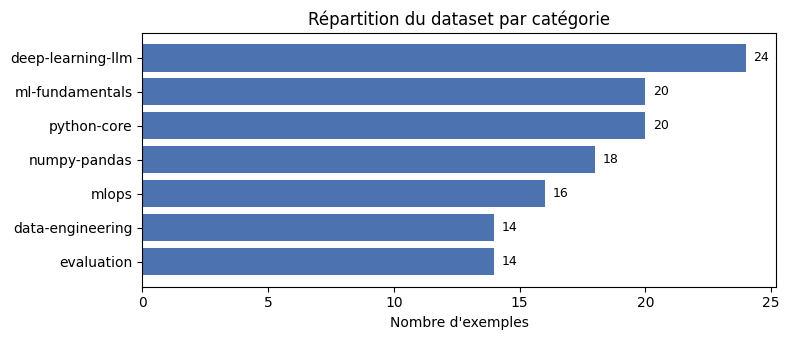

Exemple — data-engineering
Q: Pourquoi et comment nettoyer un jeu de donnees avant l'entrainement ?
R: La qualite des donnees plafonne la qualite du modele. Le nettoyage vise a supprimer les doublons, qui biaisent l'apprentissage et faussent l'evaluation s'ils traversent le split ; retirer les exemples vides, trop courts ou mal formes ; normaliser l'encodage et les espaces ; filtr ...


In [2]:
import matplotlib.pyplot as plt

raw = json.load(open(ROOT / "data" / "raw" / "raw_qa_data.json", encoding="utf-8"))
print(f"{len(raw)} exemples au total\n")

# Repartition par categorie
from collections import Counter
cats = Counter(item["category"] for item in raw)

fig, ax = plt.subplots(figsize=(8, 3.5))
names = [c for c, _ in cats.most_common()]
vals = [cats[c] for c in names]
ax.barh(names[::-1], vals[::-1], color="#4C72B0")
ax.set_xlabel("Nombre d'exemples")
ax.set_title("Répartition du dataset par catégorie")
for i, v in enumerate(vals[::-1]):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=9)
plt.tight_layout(); plt.show()

# Un exemple
ex = raw[0]
print("Exemple —", ex["category"])
print("Q:", ex["instruction"])
print("R:", ex["output"][:280], "...")

## 3. Courbe d'apprentissage

Loss d'entraînement et de validation au fil des steps (lue depuis l'état du
`Trainer`).

La loss d'entraînement descend continûment, mais celle de **validation atteint
son minimum vers 1 epoch puis remonte** : au-delà, le modèle sur-apprend. C'est
`load_best_model_at_end` qui conserve le meilleur checkpoint, complété par un
early stopping.

> 💡 Ce diagnostic n'était **pas visible** dans la v1 du projet : une fuite de
> données faisait décroître la validation artificiellement. Voir la section
> « Correction méthodologique » du README.

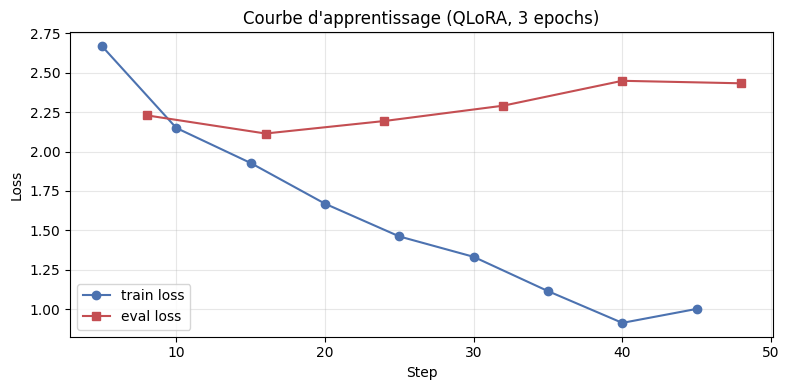

eval loss : 2.230 -> 2.433


In [3]:
def load_log_history():
    # Cherche le trainer_state.json le plus avance (checkpoints ignores par git,
    # d'ou un repli sur les valeurs du run documente si absent).
    states = sorted((ROOT / "outputs").glob("**/trainer_state.json"),
                    key=lambda p: p.stat().st_mtime) if (ROOT / "outputs").exists() else []
    if states:
        return json.load(open(states[-1]))["log_history"]
    # Repli : valeurs reelles du run v2 (dataset sans fuite)
    return [
        {"step": 5, "loss": 2.669}, {"step": 8, "eval_loss": 2.230},
        {"step": 10, "loss": 2.149}, {"step": 15, "loss": 1.927},
        {"step": 16, "eval_loss": 2.114}, {"step": 20, "loss": 1.669},
        {"step": 24, "eval_loss": 2.194}, {"step": 25, "loss": 1.461},
        {"step": 30, "loss": 1.332}, {"step": 32, "eval_loss": 2.291},
        {"step": 35, "loss": 1.114}, {"step": 40, "loss": 0.912,
                                      "eval_loss": 2.449},
        {"step": 45, "loss": 1.001}, {"step": 48, "eval_loss": 2.433},
    ]

hist = load_log_history()
tr = [(h["step"], h["loss"]) for h in hist if "loss" in h]
ev = [(h["step"], h["eval_loss"]) for h in hist if "eval_loss" in h]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(*zip(*tr), "o-", label="train loss", color="#4C72B0")
ax.plot(*zip(*ev), "s-", label="eval loss", color="#C44E52")
ax.set_xlabel("Step"); ax.set_ylabel("Loss")
ax.set_title("Courbe d'apprentissage (QLoRA, 3 epochs)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"eval loss : {ev[0][1]:.3f} -> {ev[-1][1]:.3f}")

## 4. Gain mesuré du fine-tuning

Comparaison sur le jeu de test — **strictement disjoint** de l'entraînement —
entre le modèle de base et le modèle fine-tuné.

Les barres d'erreur sont les **intervalles de confiance à 95 %** obtenus par
bootstrap. Sur un jeu de test de 24 exemples, un écart sans mesure d'incertitude
ne prouve rien : ce qui compte est que les intervalles **ne se recouvrent pas**.

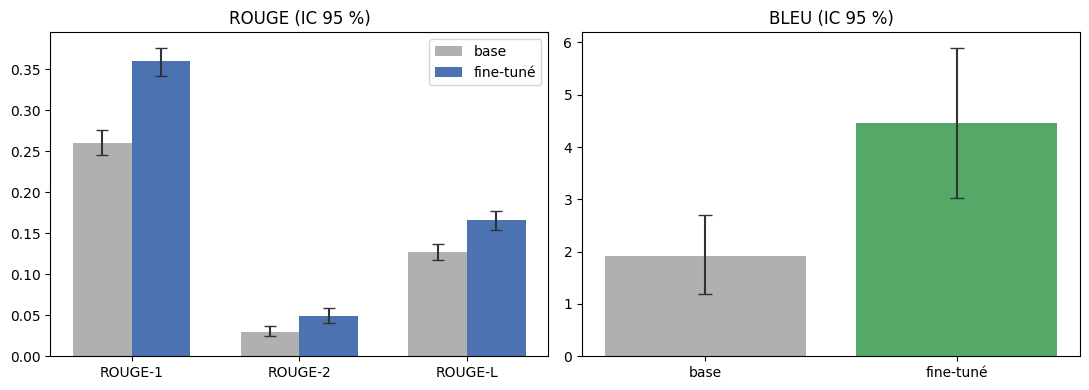

n = 24 exemples de test

ROUGE-1 : 0.260 -> 0.359 (+38 %)  IC disjoints
ROUGE-L : 0.127 -> 0.166 (+31 %)  IC disjoints
BLEU    : 1.920 -> 4.458 (+132 %)  IC disjoints


In [4]:
metrics = json.load(open(ROOT / "outputs" / "qwen2.5-3b-pyds-lora" / "eval_metrics.json"))
base, ft = metrics["baseline"], metrics["finetuned"]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))

# --- ROUGE (echelle 0-1) ---
labels, keys = ["ROUGE-1", "ROUGE-2", "ROUGE-L"], ["rouge1", "rouge2", "rougeL"]
x, w = range(len(labels)), 0.35
for offset, m, lab, col in ((-w/2, base, "base", "#B0B0B0"),
                            (w/2, ft, "fine-tuné", "#4C72B0")):
    a1.bar([i + offset for i in x], [m[k] for k in keys], w, label=lab, color=col,
           yerr=[[m[k] - m["ci95"][k][0] for k in keys],
                 [m["ci95"][k][1] - m[k] for k in keys]],
           capsize=4, ecolor="#333333")
a1.set_xticks(list(x)); a1.set_xticklabels(labels)
a1.set_title("ROUGE (IC 95 %)"); a1.legend()

# --- BLEU (echelle 0-100) ---
a2.bar(["base", "fine-tuné"], [base["bleu"], ft["bleu"]],
       color=["#B0B0B0", "#55A868"], capsize=5, ecolor="#333333",
       yerr=[[base["bleu"] - base["ci95"]["bleu"][0], ft["bleu"] - ft["ci95"]["bleu"][0]],
             [base["ci95"]["bleu"][1] - base["bleu"], ft["ci95"]["bleu"][1] - ft["bleu"]]])
a2.set_title("BLEU (IC 95 %)")
plt.tight_layout(); plt.show()

print(f"n = {ft['n_samples']} exemples de test\n")
for k, lab in (("rouge1", "ROUGE-1"), ("rougeL", "ROUGE-L"), ("bleu", "BLEU   ")):
    disjoint = ft["ci95"][k][0] > base["ci95"][k][1]
    print(f"{lab} : {base[k]:.3f} -> {ft[k]:.3f} "
          f"({(ft[k]-base[k])/base[k]*100:+.0f} %)  "
          f"{'IC disjoints' if disjoint else 'IC qui se recouvrent'}")

## 5. Démonstration en direct

On charge le modèle de base **quantisé en 4-bit** + l'**adaptateur LoRA**, puis
on génère des réponses (température 0 pour la reproductibilité).

In [5]:
from inference import load_model, generate

model, tokenizer = load_model(cfg, adapter_path=cfg.train.output_dir, merged_path=None)

questions = [
    "Qu'est-ce que la vectorisation en Python ?",
    "Explique LoRA en deux phrases.",
    "Quelle est la différence entre .loc et .iloc dans Pandas ?",
]
for q in questions:
    print("=" * 78)
    print("Q :", q)
    print("-" * 78)
    print(generate(model, tokenizer, q, max_new_tokens=220, temperature=0.0))
    print()

C:\Users\milan\Documents\projets\Claude Code\IA Projects\finetuning\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Chargement base Qwen/Qwen2.5-3B-Instruct + adaptateur C:\Users\milan\Documents\projets\Claude Code\IA Projects\finetuning\outputs\qwen2.5-3b-pyds-lora


Q : Qu'est-ce que la vectorisation en Python ?
------------------------------------------------------------------------------


La vectorisation consiste a transformer une boucle imbriquee ou une operation sur chaque ligne d'un DataFrame en une seule instruction qui agit directement sur les colonnes entieres. Cela permet de decouper le travail en parallele et d'accelerer significativement l'extraction de donnees. On utilise par exemple `df['col'].map(lambda x: ...)`, `np.vectorize` ou `pandas.Series.map` pour appliquer une fonction element par element sans boucle. La memoire est souvent reduite car on stocke seulement une version compacte du tableau au lieu de copies individuelles. En pratique, il faut bien choisir ce qu'on vectorise : des operations simples comme des calculs arithmetiques sont tres rapides, mais des transformations complexes peuvent necessiter des copies intermediaires. Le choix depend de la taille du jeu de donnees et de son mode d'utilisation.

Q : Explique LoRA en deux phrases.
------------------------------------------------------------------------------


LoRA est une technique d'ajustement fin sur les poids prouvees d'un modele LLM. Elle met en place des filtres lineaires supplantes qui sont fine-taune a la fois sur le modele original et sur un modele vide. Les coefficients de ces filtres sont appliques par rapport au modele original pour obtenir l'augmentation du rendu. Le gain est de 10% de parametres et de 2x de performances, sans impact sur la qualite du langage produit.

Q : Quelle est la différence entre .loc et .iloc dans Pandas ?
------------------------------------------------------------------------------


.loc selectionne par nom de colonnes ou de lignes, tandis que .iloc selectionne par position numerique. .loc prend une liste de noms ou une expression reguliere pour le filtre : il permet d'operer sur des sous-ensembles de donnees sans recopier les valeurs. .iloc utilise l'indexation pythonic, ce qui rend le code plus legible mais moins performant car il cree un nouveau DataFrame. L'utilisation se decide selon le cas : .loc est preferable lorsque le filtre depend du contenu des colonnes, tandis que .iloc est plus rapide lorsqu'il ne depasse pas la taille de la table.



## Conclusion

En **~7 min** d'entraînement sur un GPU grand public (RTX 4070, 8 Go), le
fine-tuning QLoRA a :

- **amélioré les 4 métriques**, avec des **intervalles de confiance disjoints** —
  le gain n'est pas un artefact d'échantillonnage (ROUGE-1 **+38 %**,
  BLEU **+132 %**) ;
- adapté le **style et le format** des réponses au domaine cible ;
- produit un **adaptateur de 119 Mo** (vs 6,2 Go pour le modèle complet), en
  n'entraînant que **0,96 %** des paramètres.

### Ce que ce projet montre aussi

Une première version souffrait d'une **fuite de données** : l'augmentation par
paraphrase était appliquée *avant* le découpage, si bien que les réponses de
référence du test avaient déjà été vues à l'entraînement. Elle gonflait les
scores **et masquait un sur-apprentissage**. Le correctif — split par groupe,
stratifié, augmentation réservée au train, contrôle bloquant — est documenté
dans le README.

> Les chiffres ci-dessus sont ceux du protocole **corrigé**. Ils sont plus bas
> en valeur absolue que ceux de la v1, et c'est précisément ce qui les rend
> dignes de confiance.

➡️ Code complet : [`train.py`](../train.py) · [`prepare_dataset.py`](../prepare_dataset.py) ·
[`evaluate.py`](../evaluate.py) · [`README.md`](../README.md)